Saving data.xlsx to data (55).xlsx


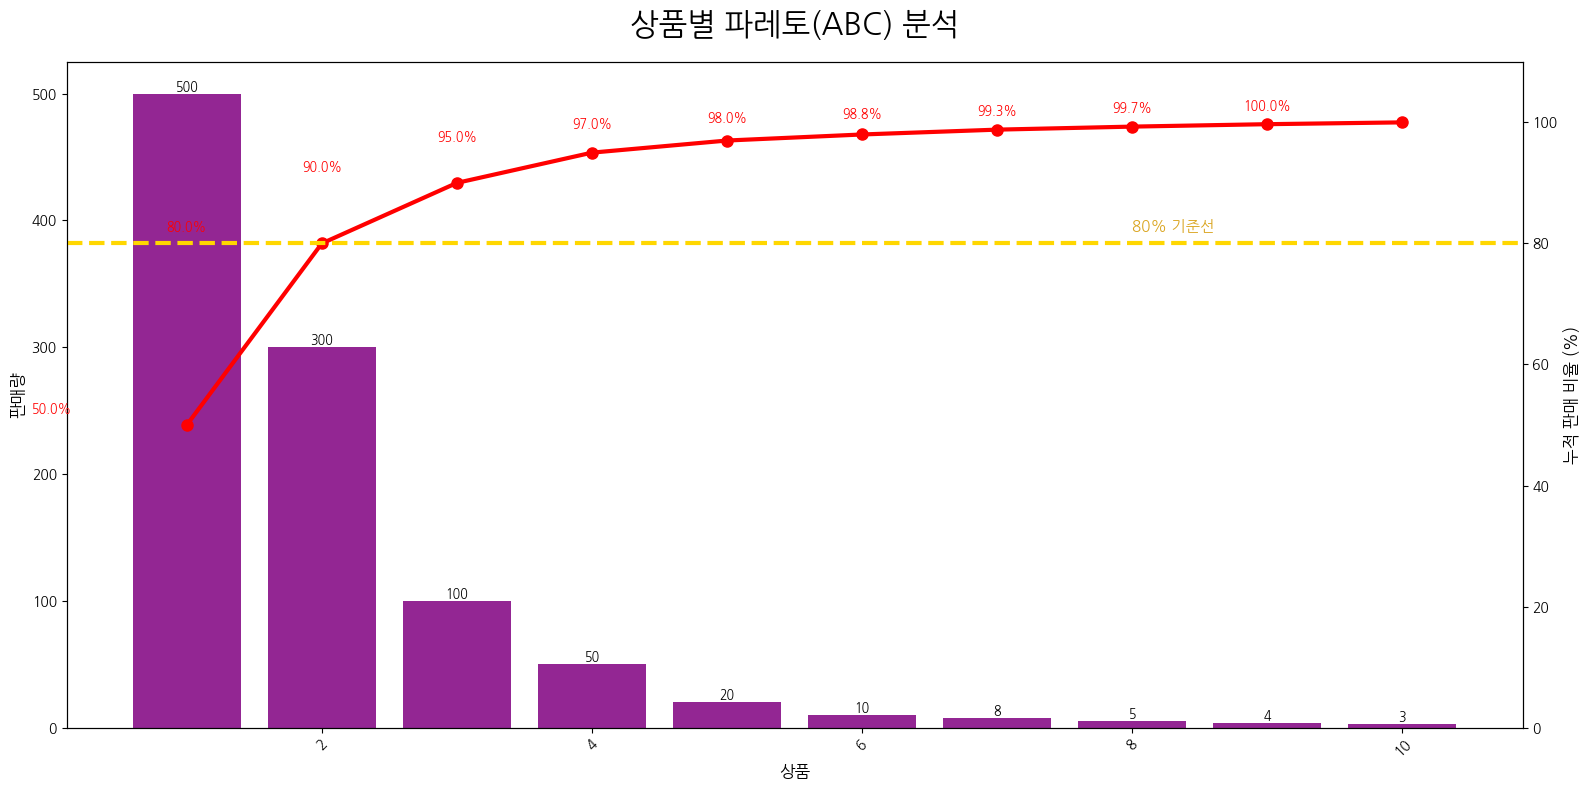



상품별 상세 분석


,상품,판매량,누적비율(%),등급
0,1,500,50.0,A
1,2,300,80.0,A
2,3,100,90.0,B
3,4,50,95.0,B
4,5,20,97.0,C
5,6,10,98.0,C
6,7,8,98.8,C
7,8,5,99.3,C
8,9,4,99.7,C
9,10,3,100.0,C




등급별 요약


,등급,상품수,총판매량,판매비중(%)
0,A,2,800,80.0
1,B,2,150,15.0
2,C,6,50,5.0




ABC 분석 결과
[A등급] 상품수 2개 | 총판매량 800 | 판매비중 80.00% → 핵심 매출 상품군으로 집중 관리가 필요합니다.
[B등급] 상품수 2개 | 총판매량 150 | 판매비중 15.00% → 성장 가능성이 있는 중간 상품군입니다.
[C등급] 상품수 6개 | 총판매량 50 | 판매비중 5.00% → 판매 비중이 낮아 재고 및 운영 효율 검토가 필요합니다.


In [78]:
# ============================================================
# 파레토(Pareto) 분석 - Google Colab 통합 코드
# 상품별 판매량 + 누적비율 + ABC 등급 분석
# ============================================================

# ============================================================
# 0. 한글 폰트 설치
# ============================================================

!apt-get -qq install fonts-nanum

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from google.colab import files

# ============================================================
# 한글 설정
# ============================================================

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()

plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

# ============================================================
# 1. 엑셀 업로드
# ============================================================

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name)

# ============================================================
# 2. 데이터 정리
# ============================================================

df = df[['상품', '판매량']]

# 판매량 기준 내림차순 정렬
df = df.sort_values(
    by='판매량',
    ascending=False
).reset_index(drop=True)

# ============================================================
# 3. 누적 판매량 및 누적비율 계산
# ============================================================

total_sales = df['판매량'].sum()

df['누적판매량'] = df['판매량'].cumsum()

df['누적비율(%)'] = round(
    df['누적판매량'] / total_sales * 100,
    2
)

# ============================================================
# 4. ABC 등급 분류
# ============================================================

def classify_grade(x):

    if x <= 80:
        return 'A'

    elif x <= 95:
        return 'B'

    else:
        return 'C'

df['등급'] = df['누적비율(%)'].apply(classify_grade)

# ============================================================
# 5. 파레토 차트
# ============================================================

fig, ax1 = plt.subplots(figsize=(16,8))

# ------------------------------------------------------------
# 판매량 막대그래프 (자주색)
# ------------------------------------------------------------

bars = ax1.bar(
    df['상품'],
    df['판매량'],
    color='purple',
    alpha=0.85
)

ax1.set_xlabel(
    '상품',
    fontsize=12,
    fontweight='bold'
)

ax1.set_ylabel(
    '판매량',
    fontsize=12,
    fontweight='bold'
)

ax1.tick_params(
    axis='x',
    rotation=45
)

# 판매량 표시

for bar in bars:

    height = bar.get_height()

    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height):,}',
        ha='center',
        va='bottom',
        fontsize=9
    )

# ------------------------------------------------------------
# 누적비율 꺾은선 그래프 (빨간색)
# ------------------------------------------------------------

ax2 = ax1.twinx()

ax2.plot(
    df['상품'],
    df['누적비율(%)'],
    color='red',
    marker='o',
    linewidth=3,
    markersize=8
)

for i, value in enumerate(df['누적비율(%)']):

    ax2.text(
        i,
        value + 2,
        f'{value:.1f}%',
        color='red',
        fontsize=9,
        ha='center'
    )

ax2.set_ylabel(
    '누적 판매 비율 (%)',
    fontsize=12,
    fontweight='bold'
)

ax2.set_ylim(0,110)

# ------------------------------------------------------------
# 80% 기준선 (노란색 점선)
# ------------------------------------------------------------

ax2.axhline(
    y=80,
    color='gold',
    linestyle='--',
    linewidth=3
)

ax2.text(
    len(df)*0.8,
    82,
    '80% 기준선',
    color='goldenrod',
    fontsize=11,
    fontweight='bold'
)

# ------------------------------------------------------------
# 제목
# ------------------------------------------------------------

plt.title(
    '상품별 파레토(ABC) 분석',
    fontsize=22,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.show()

# ============================================================
# 6. 상품별 상세 테이블
# ============================================================

detail_table = df[
    ['상품',
     '판매량',
     '누적비율(%)',
     '등급']
]

print("\n")
print("="*80)
print("상품별 상세 분석")
print("="*80)

display(detail_table)

# ============================================================
# 7. 등급별 요약 테이블
# ============================================================

summary = (
    df.groupby('등급')
      .agg(
          상품수=('상품','count'),
          총판매량=('판매량','sum')
      )
      .reset_index()
)

summary['판매비중(%)'] = round(
    summary['총판매량']
    / total_sales
    * 100,
    2
)

summary['정렬'] = summary['등급'].map(
    {'A':1, 'B':2, 'C':3}
)

summary = (
    summary
    .sort_values('정렬')
    .drop(columns='정렬')
)

print("\n")
print("="*80)
print("등급별 요약")
print("="*80)

display(summary)

# ============================================================
# 8. 등급별 해석
# ============================================================

print("\n")
print("="*80)
print("ABC 분석 결과")
print("="*80)

for _, row in summary.iterrows():

    grade = row['등급']
    cnt = row['상품수']
    sales = row['총판매량']
    ratio = row['판매비중(%)']

    if grade == 'A':
        comment = '핵심 매출 상품군으로 집중 관리가 필요합니다.'

    elif grade == 'B':
        comment = '성장 가능성이 있는 중간 상품군입니다.'

    else:
        comment = '판매 비중이 낮아 재고 및 운영 효율 검토가 필요합니다.'

    print(
        f'[{grade}등급] '
        f'상품수 {cnt}개 | '
        f'총판매량 {sales:,} | '
        f'판매비중 {ratio:.2f}% → '
        f'{comment}'
    )